In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
# import seaborn as sns 

In [7]:
df = pd.read_excel('thyroid_dataset.xlsx')

In [8]:
df.head()

,Patient_ID,Age,Sex,Pregnant,Family_History_Thyroid,On_Thyroid_Meds,TSH_mIUL,T3_nmolL,T4_nmolL,FreeT4_pmolL,FreeT3_pmolL,TG_Antibody_IUmL,TPO_Antibody_IUmL,Heart_Rate_bpm,BMI,Label,Diagnosis
0,PT0001,56,Female,0,1,0,0.949,1.76,82.6,11.37,4.44,5.4,8.1,65,25.0,0,Normal
1,PT0002,69,Male,0,0,0,0.035,4.21,184.8,26.53,10.18,22.8,NaN,88,25.9,1,Hyperthyroid
2,PT0003,46,Female,0,0,0,1.370,2.34,72.3,17.08,6.54,15.8,4.0,76,25.4,0,Normal
3,PT0004,32,Male,0,0,1,1.399,1.92,107.2,16.43,4.98,1.7,3.7,83,23.6,0,Normal
4,PT0005,60,Female,0,1,0,1.799,1.96,116.0,19.91,3.94,3.4,3.2,57,27.3,0,Normal


In [9]:
df.isnull().sum()

Patient_ID                 0
Age                        0
Sex                        0
Pregnant                   0
Family_History_Thyroid     0
On_Thyroid_Meds            0
TSH_mIUL                   0
T3_nmolL                   0
T4_nmolL                   0
FreeT4_pmolL               0
FreeT3_pmolL              32
TG_Antibody_IUmL          27
TPO_Antibody_IUmL         36
Heart_Rate_bpm             0
BMI                        0
Label                      0
Diagnosis                  0
dtype: int64

In [10]:
df = df.dropna()

In [12]:
df.isnull().sum()

Patient_ID                0
Age                       0
Sex                       0
Pregnant                  0
Family_History_Thyroid    0
On_Thyroid_Meds           0
TSH_mIUL                  0
T3_nmolL                  0
T4_nmolL                  0
FreeT4_pmolL              0
FreeT3_pmolL              0
TG_Antibody_IUmL          0
TPO_Antibody_IUmL         0
Heart_Rate_bpm            0
BMI                       0
Label                     0
Diagnosis                 0
dtype: int64

In [13]:
df.describe()

,Age,Pregnant,Family_History_Thyroid,On_Thyroid_Meds,TSH_mIUL,T3_nmolL,T4_nmolL,FreeT4_pmolL,FreeT3_pmolL,TG_Antibody_IUmL,TPO_Antibody_IUmL,Heart_Rate_bpm,BMI,Label
count,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.00000,908.000000,908.000000
mean,50.113436,0.041850,0.274229,0.180617,1.347778,2.580969,123.066850,20.474604,6.443106,20.255617,27.884361,82.73348,23.932379,0.288546
std,18.063447,0.200357,0.446371,0.384912,1.146541,1.317012,41.857958,8.293474,2.575035,39.838265,64.339029,15.59293,4.120785,0.453336
min,18.000000,0.000000,0.000000,0.000000,0.009000,0.940000,51.300000,7.170000,2.440000,0.300000,0.300000,46.00000,14.000000,0.000000
25%,35.000000,0.000000,0.000000,0.000000,0.089000,1.680000,93.275000,14.630000,4.667500,3.200000,3.175000,71.00000,20.900000,0.000000
50%,50.000000,0.000000,0.000000,0.000000,1.285000,1.950000,109.900000,17.300000,5.330000,6.300000,7.300000,81.00000,24.000000,0.000000
75%,66.000000,0.000000,1.000000,0.000000,1.961000,3.685000,148.800000,26.160000,8.352500,17.600000,20.225000,92.00000,26.700000,1.000000
max,79.000000,1.000000,1.000000,1.000000,6.858000,6.890000,241.800000,47.780000,14.400000,399.300000,687.000000,130.00000,38.700000,1.000000


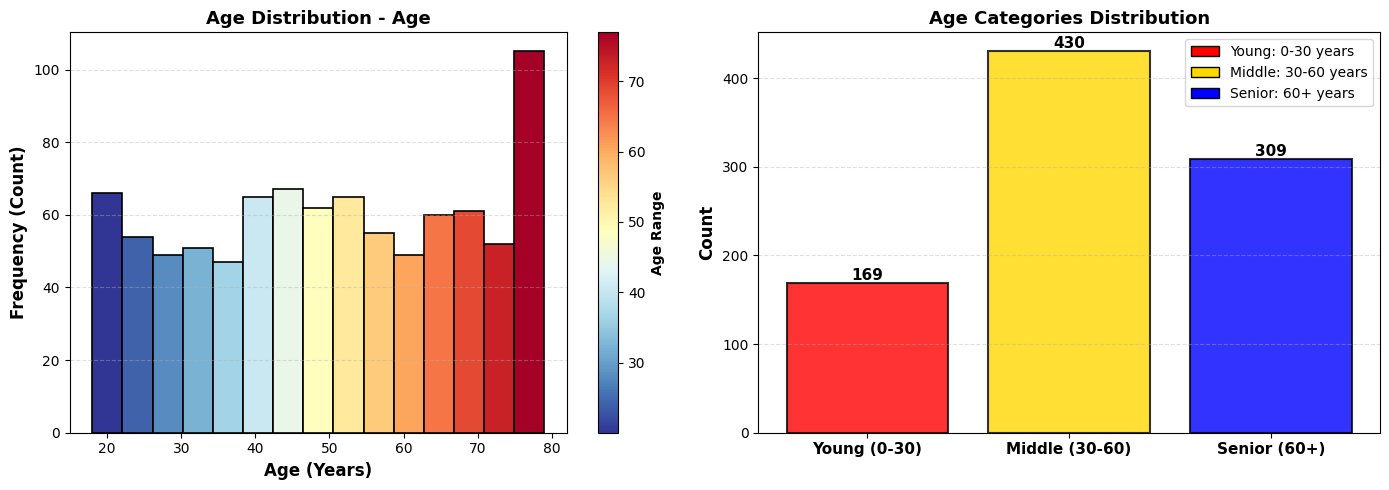

AGE DISTRIBUTION STATISTICS

Age Statistics:
  Min Age: 18.0 years
  Max Age: 79.0 years
  Mean Age: 50.1 years
  Median Age: 50.0 years

Category Breakdown:
  Young (0-30): 169 (18.6%)
  Middle (30-60): 430 (47.4%)
  Senior (60+): 309 (34.0%)


In [18]:
# AGE DISTRIBUTION with Red to Blue Color Gradient & Legends

# Find age column (common names in thyroid datasets)
age_col = None
for col in df.columns:
    if 'age' in col.lower():
        age_col = col
        break

if age_col:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # PLOT 1: Histogram with Red-to-Blue Gradient
    ax1 = axes[0]
    
    # Create bins manually to apply gradient colors
    n_bins = 15
    counts, bins, patches = ax1.hist(df[age_col], bins=n_bins, edgecolor='black', linewidth=1.2)
    
    # Apply red-to-blue colormap
    cm = plt.cm.RdYlBu_r  # Red to Blue colormap (reversed)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    col_vals = (bin_centers - bin_centers.min()) / (bin_centers.max() - bin_centers.min())
    
    for c, p in zip(col_vals, patches):
        plt.setp(p, 'facecolor', cm(c))
    
    ax1.set_xlabel('Age (Years)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Frequency (Count)', fontsize=12, fontweight='bold')
    ax1.set_title(f'Age Distribution - {age_col}', fontsize=13, fontweight='bold')
    ax1.grid(axis='y', alpha=0.4, linestyle='--')
    
    # Add colorbar legend
    sm = plt.cm.ScalarMappable(cmap=cm, norm=plt.Normalize(vmin=bin_centers.min(), vmax=bin_centers.max()))
    sm.set_array([])
    cbar1 = plt.colorbar(sm, ax=ax1)
    cbar1.set_label('Age Range', fontweight='bold')
    
    # PLOT 2: Age distribution with categories (Young/Middle/Senior)
    ax2 = axes[1]
    
    # Create age categories
    age_categories = pd.cut(df[age_col], bins=[0, 30, 60, 100], 
                            labels=['Young (0-30)', 'Middle (30-60)', 'Senior (60+)'])
    
    category_counts = age_categories.value_counts().sort_index()
    colors_cat = ['#FF0000', '#FFD700', '#0000FF']  # Red, Yellow, Blue
    
    bars = ax2.bar(range(len(category_counts)), category_counts.values, color=colors_cat, 
                   edgecolor='black', linewidth=1.5, alpha=0.8)
    
    ax2.set_xticks(range(len(category_counts)))
    ax2.set_xticklabels(category_counts.index, fontsize=11, fontweight='bold')
    ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax2.set_title('Age Categories Distribution', fontsize=13, fontweight='bold')
    ax2.grid(axis='y', alpha=0.4, linestyle='--')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Add legend
    legend_labels = ['Young: 0-30 years', 'Middle: 30-60 years', 'Senior: 60+ years']
    ax2.legend([plt.Rectangle((0,0),1,1, fc=colors_cat[i], edgecolor='black') 
               for i in range(3)], legend_labels, loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("=" * 50)
    print(f"AGE DISTRIBUTION STATISTICS")
    print("=" * 50)
    print(f"\nAge Statistics:")
    print(f"  Min Age: {df[age_col].min():.1f} years")
    print(f"  Max Age: {df[age_col].max():.1f} years")
    print(f"  Mean Age: {df[age_col].mean():.1f} years")
    print(f"  Median Age: {df[age_col].median():.1f} years")
    print(f"\nCategory Breakdown:")
    for cat, count in category_counts.items():
        percentage = (count / len(df)) * 100
        print(f"  {cat}: {count} ({percentage:.1f}%)")
    print("=" * 50)
else:
    print(" Age column not found! Available columns:")
    print(df.columns.tolist())

In [19]:
df.info()

<class 'pandas.DataFrame'>
Index: 908 entries, 0 to 998
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Patient_ID              908 non-null    str    
 1   Age                     908 non-null    int64  
 2   Sex                     908 non-null    str    
 3   Pregnant                908 non-null    int64  
 4   Family_History_Thyroid  908 non-null    int64  
 5   On_Thyroid_Meds         908 non-null    int64  
 6   TSH_mIUL                908 non-null    float64
 7   T3_nmolL                908 non-null    float64
 8   T4_nmolL                908 non-null    float64
 9   FreeT4_pmolL            908 non-null    float64
 10  FreeT3_pmolL            908 non-null    float64
 11  TG_Antibody_IUmL        908 non-null    float64
 12  TPO_Antibody_IUmL       908 non-null    float64
 13  Heart_Rate_bpm          908 non-null    int64  
 14  BMI                     908 non-null    float64
 15  Label

In [20]:
df['Sex'].value_counts()

Sex
Female    626
Male      282
Name: count, dtype: int64

In [24]:
df['Pregnant'].value_counts()

Pregnant
0    870
1     38
Name: count, dtype: int64

In [29]:
# Find relevant columns
print(" Looking for Sex/Gender column...")
sex_col = None
for col in df.columns:
    if 'sex' in col.lower() or 'gender' in col.lower():
        sex_col = col
        print(f"Found: {sex_col}")
        print(f" Values: {df[sex_col].value_counts().to_dict()}")
        break

print("\n🔍 Looking for Thyroid column...")
thyroid_col = None
for col in df.columns:
    if 'thyroid' in col.lower() or col.lower() in ['target', 'label', 'class']:
        thyroid_col = col
        print(f"✓ Found: {thyroid_col}")
        print(f"  Values: {df[thyroid_col].value_counts().to_dict()}")
        break

print("\n🔍 Looking for Pregnancy column...")
preg_col = None
for col in df.columns:
    if 'preg' in col.lower():
        preg_col = col
        print(f"Found: {preg_col}")
        print(f" Values: {df[preg_col].value_counts().to_dict()}")
        break

if not (sex_col and thyroid_col):
    print("\n All columns in dataset:")
    for i, col in enumerate(df.columns):
        print(f"  {i}: {col}")

 Looking for Sex/Gender column...
Found: Sex
 Values: {'Female': 626, 'Male': 282}

🔍 Looking for Thyroid column...
✓ Found: Family_History_Thyroid
  Values: {0: 659, 1: 249}

🔍 Looking for Pregnancy column...
Found: Pregnant
 Values: {0: 870, 1: 38}


ANALYSIS 1: THYROID DISEASE BY SEX

Thyroid Cases by Sex (Family_History_Thyroid = 1):
Sex
Female    173
Male       76
Name: count, dtype: int64

Total with thyroid family history: 249
Percentage - Female: 69.5%
Percentage - Male: 30.5%


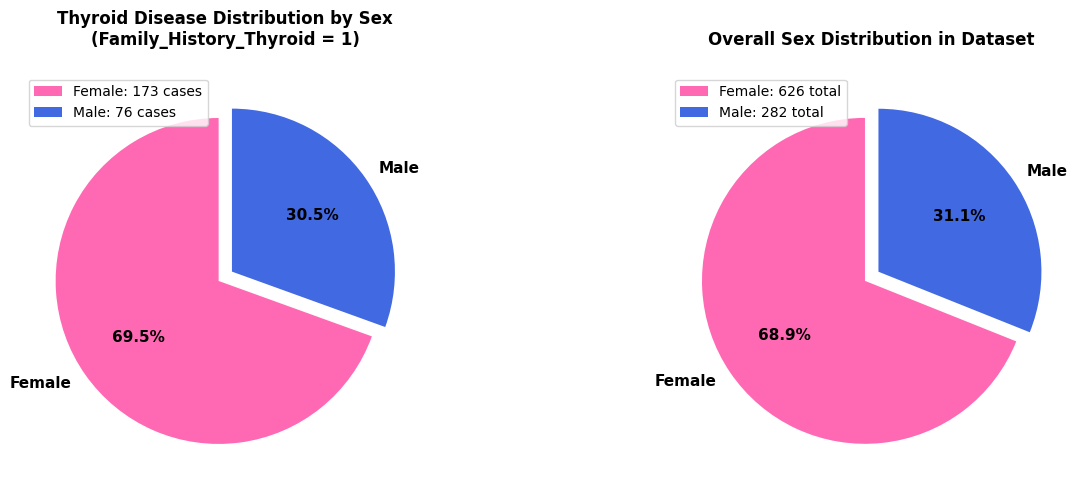

In [34]:
# ANALYSIS 1: Which Sex has more Thyroid - PIE CHART
print("=" * 70)
print("ANALYSIS 1: THYROID DISEASE BY SEX")
print("=" * 70)

# Filter data: 1 = has thyroid family history
thyroid_patients = df[df['Family_History_Thyroid'] == 1]

# Count by sex
sex_counts = thyroid_patients['Sex'].value_counts()
print(f"\nThyroid Cases by Sex (Family_History_Thyroid = 1):")
print(sex_counts)
print(f"\nTotal with thyroid family history: {len(thyroid_patients)}")
print(f"Percentage - Female: {(sex_counts.get('Female', 0) / len(thyroid_patients) * 100):.1f}%")
print(f"Percentage - Male: {(sex_counts.get('Male', 0) / len(thyroid_patients) * 100):.1f}%")

# Create pie charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie Chart 1: Thyroid cases by Sex
colors_sex = ['#FF69B4', '#4169E1']  # Pink for Female, Blue for Male
explode = (0.05, 0.05)

axes[0].pie(sex_counts.values, labels=sex_counts.index, autopct='%1.1f%%', 
           colors=colors_sex, explode=explode, startangle=90, 
           textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[0].set_title('Thyroid Disease Distribution by Sex\n(Family_History_Thyroid = 1)', 
                 fontsize=12, fontweight='bold', pad=20)

# Add legend with counts
legend_labels = [f'{sex}: {count} cases' for sex, count in sex_counts.items()]
axes[0].legend(legend_labels, loc='upper left', fontsize=10)

# Pie Chart 2: Overall sex distribution in dataset
all_sex_counts = df['Sex'].value_counts()
axes[1].pie(all_sex_counts.values, labels=all_sex_counts.index, autopct='%1.1f%%',
           colors=colors_sex, explode=explode, startangle=90,
           textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Overall Sex Distribution in Dataset', 
                 fontsize=12, fontweight='bold', pad=20)

legend_labels_all = [f'{sex}: {count} total' for sex, count in all_sex_counts.items()]
axes[1].legend(legend_labels_all, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()




🤰 ANALYSIS 2: THYROID IN PREGNANT vs NON-PREGNANT FEMALES

Total Females in dataset: 626
  Pregnant females: 38
  Non-pregnant females: 588

📌 THYROID DISEASE COMPARISON:
  Pregnant females WITH thyroid: 12 out of 38
    Percentage: 31.6%

  Non-pregnant females WITH thyroid: 161 out of 588
    Percentage: 27.4%


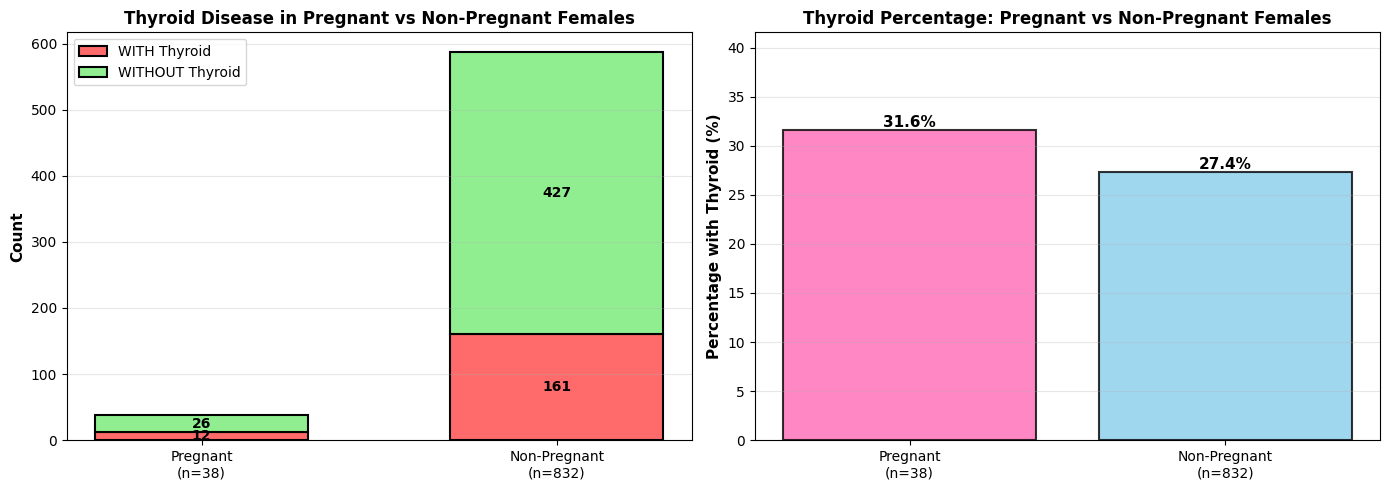


📊 CONCLUSION:
✓ YES! Pregnant females have HIGHER thyroid prevalence
  Difference: 4.2% higher in pregnant females

💡 Note: 0 = No thyroid family history, 1 = Has thyroid family history


In [35]:
# ANALYSIS 2: Do Pregnant Females have more Thyroid Disease?
print("\n" + "=" * 70)
print("🤰 ANALYSIS 2: THYROID IN PREGNANT vs NON-PREGNANT FEMALES")
print("=" * 70)

# Filter only females
females_df = df[df['Sex'] == 'Female']

# Split by pregnancy status
pregnant_females = females_df[females_df['Pregnant'] == 1]
non_pregnant_females = females_df[females_df['Pregnant'] == 0]

print(f"\nTotal Females in dataset: {len(females_df)}")
print(f"  Pregnant females: {len(pregnant_females)}")
print(f"  Non-pregnant females: {len(non_pregnant_females)}")

# Thyroid cases
pregnant_with_thyroid = len(pregnant_females[pregnant_females['Family_History_Thyroid'] == 1])
non_pregnant_with_thyroid = len(non_pregnant_females[non_pregnant_females['Family_History_Thyroid'] == 1])

print(f"\n📌 THYROID DISEASE COMPARISON:")
print(f"  Pregnant females WITH thyroid: {pregnant_with_thyroid} out of {len(pregnant_females)}")
if len(pregnant_females) > 0:
    preg_thyroid_pct = (pregnant_with_thyroid / len(pregnant_females)) * 100
    print(f"    Percentage: {preg_thyroid_pct:.1f}%")

print(f"\n  Non-pregnant females WITH thyroid: {non_pregnant_with_thyroid} out of {len(non_pregnant_females)}")
if len(non_pregnant_females) > 0:
    non_preg_thyroid_pct = (non_pregnant_with_thyroid / len(non_pregnant_females)) * 100
    print(f"    Percentage: {non_preg_thyroid_pct:.1f}%")

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Stacked bar chart
categories = ['Pregnant\n(n=38)', 'Non-Pregnant\n(n=832)']
with_thyroid = [pregnant_with_thyroid, non_pregnant_with_thyroid]
without_thyroid = [len(pregnant_females) - pregnant_with_thyroid, 
                   len(non_pregnant_females) - non_pregnant_with_thyroid]

x_pos = np.arange(len(categories))
width = 0.6

bars1 = axes[0].bar(x_pos, with_thyroid, width, label='WITH Thyroid', 
                    color='#FF6B6B', edgecolor='black', linewidth=1.5)
bars2 = axes[0].bar(x_pos, without_thyroid, width, bottom=with_thyroid, 
                    label='WITHOUT Thyroid', color='#90EE90', edgecolor='black', linewidth=1.5)

axes[0].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[0].set_title('Thyroid Disease in Pregnant vs Non-Pregnant Females', 
                  fontsize=12, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(categories, fontsize=10)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for i, (w, wo) in enumerate(zip(with_thyroid, without_thyroid)):
    axes[0].text(i, w/2, str(w), ha='center', va='center', fontweight='bold', fontsize=10)
    axes[0].text(i, w + wo/2, str(wo), ha='center', va='center', fontweight='bold', fontsize=10)

# Chart 2: Percentage comparison
percentages = [preg_thyroid_pct if len(pregnant_females) > 0 else 0, 
               non_preg_thyroid_pct if len(non_pregnant_females) > 0 else 0]
colors_bar = ['#FF69B4', '#87CEEB']

bars = axes[1].bar(categories, percentages, color=colors_bar, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[1].set_ylabel('Percentage with Thyroid (%)', fontsize=11, fontweight='bold')
axes[1].set_title('Thyroid Percentage: Pregnant vs Non-Pregnant Females', 
                  fontsize=12, fontweight='bold')
axes[1].set_ylim(0, max(percentages) + 10)
axes[1].grid(axis='y', alpha=0.3)

# Add percentage labels
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Conclusion
print("\n" + "=" * 70)
print("📊 CONCLUSION:")
print("=" * 70)
if preg_thyroid_pct > non_preg_thyroid_pct:
    diff = preg_thyroid_pct - non_preg_thyroid_pct
    print(f"✓ YES! Pregnant females have HIGHER thyroid prevalence")
    print(f"  Difference: {diff:.1f}% higher in pregnant females")
else:
    diff = non_preg_thyroid_pct - preg_thyroid_pct
    print(f"✗ NO. Non-pregnant females have HIGHER thyroid prevalence")
    print(f"  Difference: {diff:.1f}% higher in non-pregnant females")

print(f"\n💡 Note: 0 = No thyroid family history, 1 = Has thyroid family history")
print("=" * 70)

In [ ]:
print("="*80)
print("BOX PLOTS - OUTLIER DETECTION")
print("="*80)

numeric_cols_list = df.select_dtypes(include=[np.number]).columns.tolist()

if numeric_cols_list:
    n_cols = len(numeric_cols_list)
    n_rows = (n_cols + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4*n_rows))
    axes = axes.flatten()
    
    for idx, col in enumerate(numeric_cols_list):
        data = df[col].dropna()
        axes[idx].boxplot(data, vert=True)
        axes[idx].set_title(f'{col}', fontweight='bold', fontsize=11)
        axes[idx].set_ylabel('Value', fontsize=10)
        axes[idx].grid(axis='y', alpha=0.3)
        
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((data < lower_bound) | (data > upper_bound)).sum()
        
        stat = f'Outliers: {outliers}\nMean: {data.mean():.2f}\nStd: {data.std():.2f}'
        axes[idx].text(1.3, data.max(), stat, fontsize=8, verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))
    
    for idx in range(len(numeric_cols_list), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Box Plots - Outlier Detection', fontsize=13, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    
    print("Box plot analysis complete")
else:
    print("No numeric columns found")

In [ ]:
print("="*80)
print("BINARY FEATURES FREQUENCY")
print("="*80)

binary_features = [col for col in df.columns if df[col].dtype in [int, float] and df[col].nunique() <= 2]

feature_counts = {}
for col in binary_features:
    yes_count = (df[col] == 1).sum()
    feature_counts[col] = yes_count

sorted_features = dict(sorted(feature_counts.items(), key=lambda x: x[1], reverse=True))

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.Set3(np.linspace(0, 1, len(sorted_features)))
bars = ax.barh(list(sorted_features.keys()), list(sorted_features.values()), 
              color=colors, edgecolor='black', linewidth=1)

ax.set_xlabel('Count (Value = 1)', fontsize=11, fontweight='bold')
ax.set_title('Binary Features Frequency', fontsize=13, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

for i, bar in enumerate(bars):
    width = bar.get_width()
    pct = (width / len(df)) * 100
    ax.text(width, bar.get_y() + bar.get_height()/2, f'{int(width)} ({pct:.1f}%)',
           ha='left', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("Binary features analysis complete")

NUMERICAL STATISTICS SUMMARY TABLE


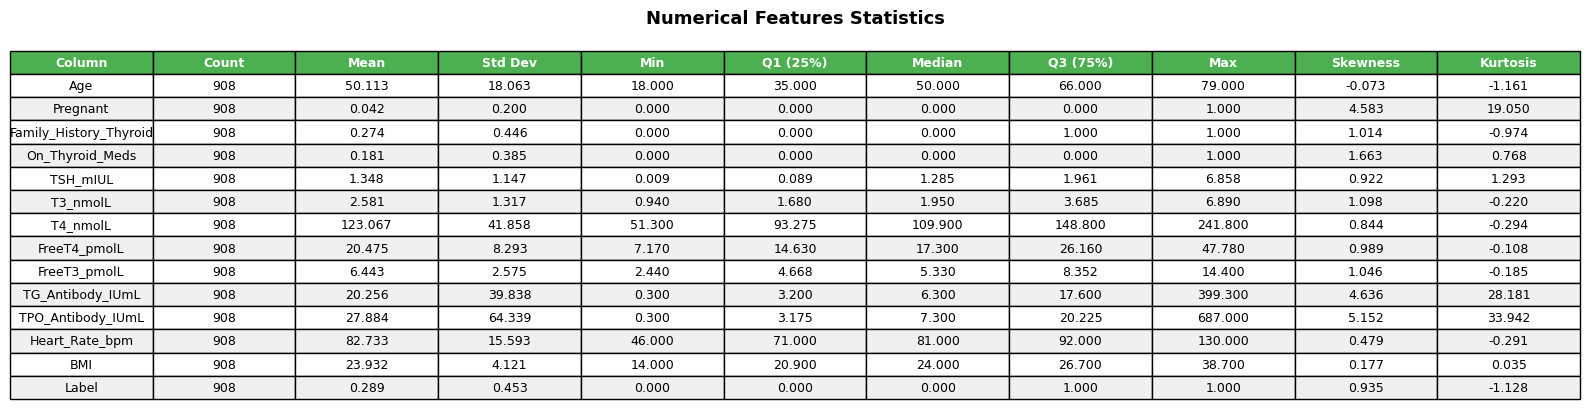


Statistics Summary:
                    Column  Count     Mean Std Dev     Min Q1 (25%)   Median Q3 (75%)      Max Skewness Kurtosis
0                      Age    908   50.113  18.063  18.000   35.000   50.000   66.000   79.000   -0.073   -1.161
1                 Pregnant    908    0.042   0.200   0.000    0.000    0.000    0.000    1.000    4.583   19.050
2   Family_History_Thyroid    908    0.274   0.446   0.000    0.000    0.000    1.000    1.000    1.014   -0.974
3          On_Thyroid_Meds    908    0.181   0.385   0.000    0.000    0.000    0.000    1.000    1.663    0.768
4                 TSH_mIUL    908    1.348   1.147   0.009    0.089    1.285    1.961    6.858    0.922    1.293
5                 T3_nmolL    908    2.581   1.317   0.940    1.680    1.950    3.685    6.890    1.098   -0.220
6                 T4_nmolL    908  123.067  41.858  51.300   93.275  109.900  148.800  241.800    0.844   -0.294
7             FreeT4_pmolL    908   20.475   8.293   7.170   14.630   17.30

In [51]:
print("="*80)
print("NUMERICAL STATISTICS SUMMARY TABLE")
print("="*80)

numeric_cols_list = df.select_dtypes(include=[np.number]).columns.tolist()

stats_data = []
for col in numeric_cols_list:
    data = df[col].dropna()
    stats_data.append({
        'Column': col,
        'Count': len(data),
        'Mean': f"{data.mean():.3f}",
        'Std Dev': f"{data.std():.3f}",
        'Min': f"{data.min():.3f}",
        'Q1 (25%)': f"{data.quantile(0.25):.3f}",
        'Median': f"{data.median():.3f}",
        'Q3 (75%)': f"{data.quantile(0.75):.3f}",
        'Max': f"{data.max():.3f}",
        'Skewness': f"{data.skew():.3f}",
        'Kurtosis': f"{data.kurtosis():.3f}"
    })

stats_df = pd.DataFrame(stats_data)

fig, ax = plt.subplots(figsize=(16, max(4, len(stats_df)*0.3)))
ax.axis('off')

table = ax.table(cellText=stats_df.values, colLabels=stats_df.columns, 
                cellLoc='center', loc='center', bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

for i in range(len(stats_df.columns)):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

for i in range(1, len(stats_df) + 1):
    for j in range(len(stats_df.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')
        else:
            table[(i, j)].set_facecolor('#ffffff')

plt.title('Numerical Features Statistics', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nStatistics Summary:")
print(stats_df.to_string())
print("\nTable legend:")
print("Q1 = 25th percentile, Median = 50th percentile, Q3 = 75th percentile")
print("Skewness: -1 (left-skewed), 0 (normal), +1 (right-skewed)")
print("Kurtosis: Measures tail heaviness (outlier presence)")

MULTI-CONDITION ANALYSIS


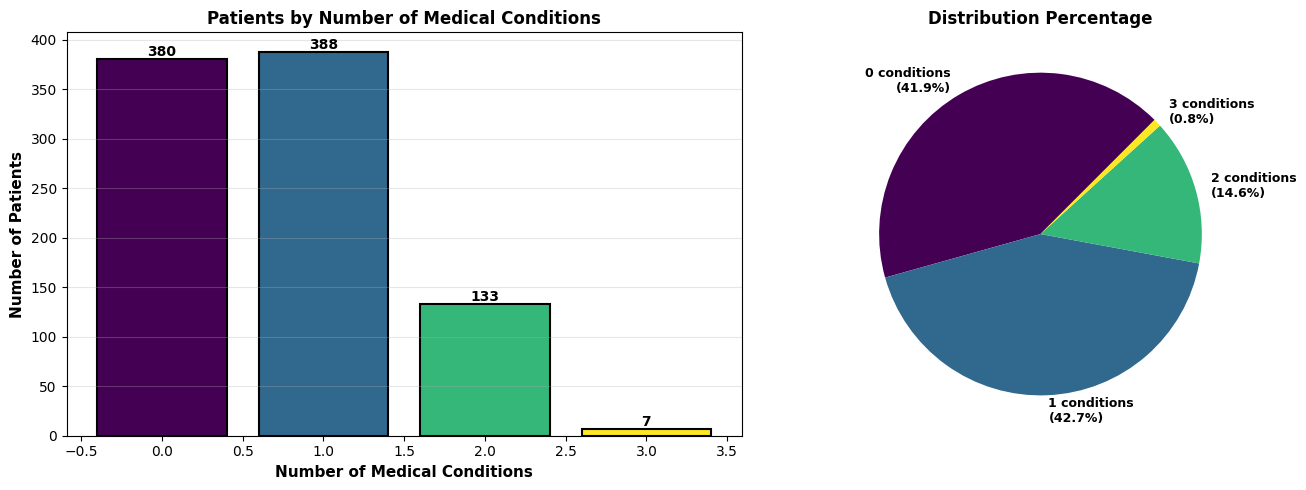


Condition Count Distribution:
0    380
1    388
2    133
3      7
Name: count, dtype: int64

Average medical conditions per patient: 0.74
Max conditions in single patient: 3


In [52]:
print("="*80)
print("MULTI-CONDITION ANALYSIS")
print("="*80)

medical_condition_cols = [col for col in df.columns if col not in ['Age', 'Sex', 'Pregnant'] 
                         and df[col].dtype in [int, float] and df[col].nunique() <= 2]

condition_counts_per_patient = (df[medical_condition_cols] == 1).sum(axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

condition_dist = condition_counts_per_patient.value_counts().sort_index()
colors = plt.cm.viridis(np.linspace(0, 1, len(condition_dist)))

bars = ax1.bar(condition_dist.index, condition_dist.values, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Number of Medical Conditions', fontsize=11, fontweight='bold')
ax1.set_ylabel('Number of Patients', fontsize=11, fontweight='bold')
ax1.set_title('Patients by Number of Medical Conditions', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

condition_pct = (condition_dist / len(df)) * 100
ax2.pie(condition_dist.values, labels=[f'{int(x)} conditions\n({pct:.1f}%)' 
        for x, pct in zip(condition_dist.index, condition_pct)],
        autopct='', colors=colors, startangle=45, textprops={'fontsize': 9, 'fontweight': 'bold'})
ax2.set_title('Distribution Percentage', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nCondition Count Distribution:")
print(condition_dist)
print(f"\nAverage medical conditions per patient: {condition_counts_per_patient.mean():.2f}")
print(f"Max conditions in single patient: {condition_counts_per_patient.max()}")

TARGET VARIABLE ANALYSIS


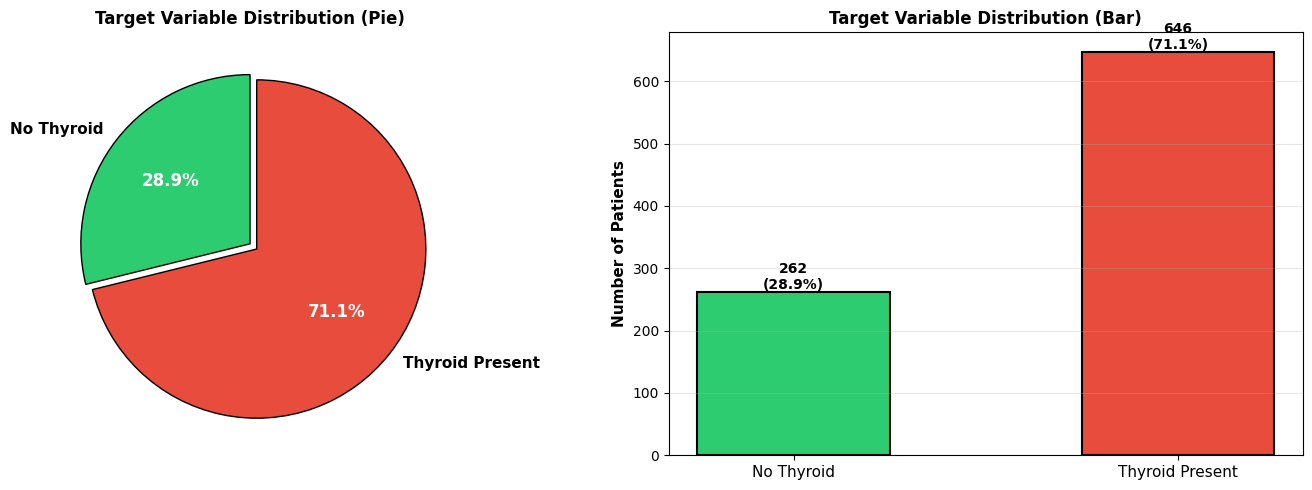


Diagnosis Distribution:
Diagnosis
Hyperthyroid    262
Normal          646
Name: count, dtype: int64

Class Balance: 28.9% vs 71.1%
Imbalance Ratio: 2.47:1


In [53]:
print("="*80)
print("TARGET VARIABLE ANALYSIS")
print("="*80)

# If 'diagnosis' or similar target column exists
target_col = None
for col in df.columns:
    if 'diagnosis' in col.lower() or 'target' in col.lower() or 'class' in col.lower():
        target_col = col
        break

if target_col is None:
    # Try to identify binary target by looking for columns with 0/1 values
    possible_targets = [col for col in df.columns if df[col].dtype in [int, float] 
                       and set(df[col].unique()).issubset({0.0, 1.0})]
    if possible_targets:
        target_col = possible_targets[0]

if target_col:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Decision if target is disease presence (thyroid)
    target_counts = df[target_col].value_counts().sort_index()
    colors_target = ['#2ecc71', '#e74c3c']
    labels_target = ['No Thyroid', 'Thyroid Present']
    
    explode = (0, 0.05) if len(target_counts) == 2 else None
    wedges, texts, autotexts = ax1.pie(target_counts.values, 
                                         labels=labels_target,
                                         autopct='%1.1f%%',
                                         colors=colors_target,
                                         explode=explode,
                                         startangle=90,
                                         wedgeprops={'edgecolor': 'black', 'linewidth': 1},
                                         textprops={'fontsize': 11, 'fontweight': 'bold'})
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(12)
        autotext.set_fontweight('bold')
    
    ax1.set_title('Target Variable Distribution (Pie)', fontsize=12, fontweight='bold')
    
    # Bar chart
    bars = ax2.bar(range(len(target_counts)), target_counts.values, color=colors_target, 
                    edgecolor='black', linewidth=1.5, width=0.5)
    ax2.set_xticks(range(len(target_counts)))
    ax2.set_xticklabels(labels_target, fontsize=11)
    ax2.set_ylabel('Number of Patients', fontsize=11, fontweight='bold')
    ax2.set_title('Target Variable Distribution (Bar)', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    for i, bar in enumerate(bars):
        height = bar.get_height()
        pct = (target_counts.values[i] / len(df)) * 100
        ax2.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}\n({pct:.1f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{target_col} Distribution:")
    print(target_counts)
    print(f"\nClass Balance: {(target_counts.values[0] / len(df) * 100):.1f}% vs {(target_counts.values[1] / len(df) * 100):.1f}%")
    print(f"Imbalance Ratio: {max(target_counts.values) / min(target_counts.values):.2f}:1")
else:
    print("No target variable identified in dataset")

DATA QUALITY & COMPLETENESS CHECK

Dataset Shape: (908, 17)
Total Records: 908
Total Features: 17

Numeric Features: 14
Categorical Features: 3

Data Types Distribution:
  float64: 8 columns
  int64: 6 columns
  str: 3 columns

Missing Values: 0 total (0.00% of data)
Duplicate Rows: 0

Columns with >50% zeros (potential missing indicator):
  Pregnant: 95.8% zeros
  Family_History_Thyroid: 72.6% zeros
  On_Thyroid_Meds: 81.9% zeros
  Label: 71.1% zeros


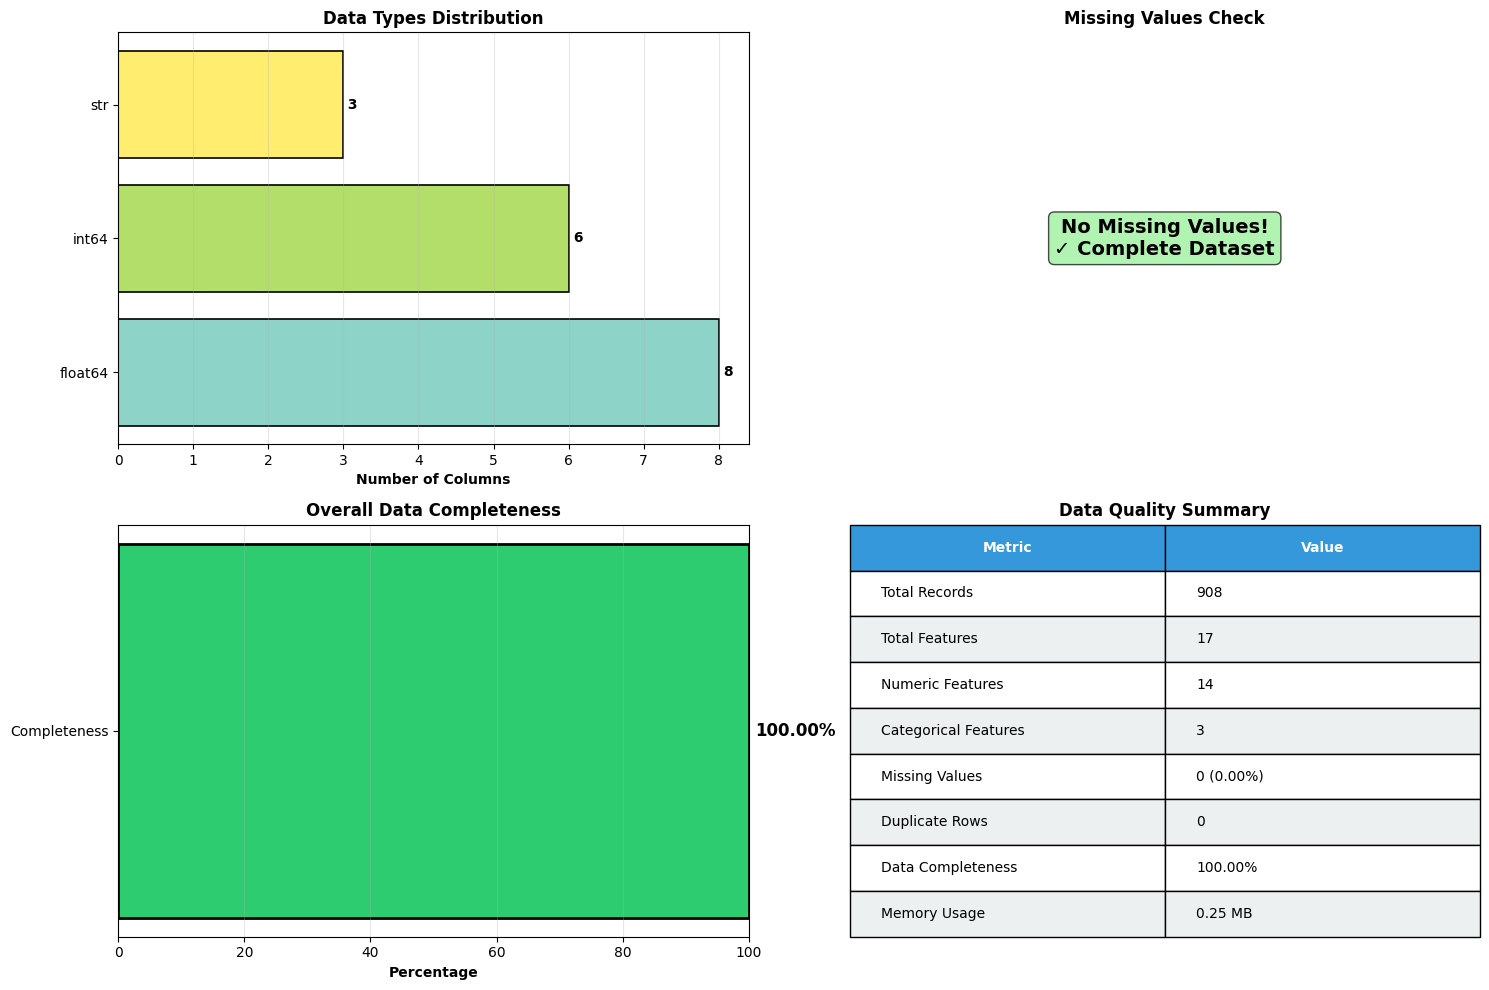

In [54]:
print("="*80)
print("DATA QUALITY & COMPLETENESS CHECK")
print("="*80)

# Missing values
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100

# Duplicates
duplicates = df.duplicated().sum()

# Data types
dtype_counts = df.dtypes.value_counts()

# Numeric columns stats
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nDataset Shape: {df.shape}")
print(f"Total Records: {len(df)}")
print(f"Total Features: {len(df.columns)}")
print(f"\nNumeric Features: {len(numeric_cols)}")
print(f"Categorical Features: {len(df.columns) - len(numeric_cols)}")

print(f"\nData Types Distribution:")
for dtype, count in dtype_counts.items():
    print(f"  {dtype}: {count} columns")

print(f"\nMissing Values: {missing_count.sum()} total ({(missing_count.sum() / (len(df) * len(df.columns)) * 100):.2f}% of data)")
print(f"Duplicate Rows: {duplicates}")

# Zeros in numeric columns (might represent missing)
print(f"\nColumns with >50% zeros (potential missing indicator):")
for col in numeric_cols:
    zero_pct = (df[col] == 0).sum() / len(df) * 100
    if zero_pct > 50:
        print(f"  {col}: {zero_pct:.1f}% zeros")

# Visualize completeness
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Data Type Distribution
dtype_names = [str(dtype) for dtype in dtype_counts.index]
colors_dtype = plt.cm.Set3(np.linspace(0, 1, len(dtype_counts)))
axes[0, 0].barh(dtype_names, dtype_counts.values, color=colors_dtype, edgecolor='black', linewidth=1.2)
axes[0, 0].set_xlabel('Number of Columns', fontweight='bold')
axes[0, 0].set_title('Data Types Distribution', fontweight='bold', fontsize=12)
for i, v in enumerate(dtype_counts.values):
    axes[0, 0].text(v, i, f' {v}', va='center', fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Missing Value % by Column (if any)
if missing_count.sum() > 0:
    missing_pct_sorted = missing_pct[missing_pct > 0].sort_values(ascending=True)
    colors_missing = plt.cm.Reds(np.linspace(0.3, 0.9, len(missing_pct_sorted)))
    axes[0, 1].barh(range(len(missing_pct_sorted)), missing_pct_sorted.values, color=colors_missing, edgecolor='black')
    axes[0, 1].set_yticks(range(len(missing_pct_sorted)))
    axes[0, 1].set_yticklabels(missing_pct_sorted.index, fontsize=9)
    axes[0, 1].set_xlabel('Missing %', fontweight='bold')
    axes[0, 1].set_title('Missing Values by Column', fontweight='bold', fontsize=12)
    for i, v in enumerate(missing_pct_sorted.values):
        axes[0, 1].text(v, i, f' {v:.1f}%', va='center', fontweight='bold')
else:
    axes[0, 1].text(0.5, 0.5, 'No Missing Values!\n✓ Complete Dataset', 
                    ha='center', va='center', fontsize=14, fontweight='bold',
                    transform=axes[0, 1].transAxes, 
                    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
    axes[0, 1].set_title('Missing Values Check', fontweight='bold', fontsize=12)
    axes[0, 1].axis('off')

# 3. Completeness bar (overall)
completeness = (1 - missing_count.sum() / (len(df) * len(df.columns))) * 100
axes[1, 0].barh(['Completeness'], [completeness], color=['#2ecc71'], height=0.5, edgecolor='black', linewidth=2)
axes[1, 0].set_xlim([0, 100])
axes[1, 0].set_xlabel('Percentage', fontweight='bold')
axes[1, 0].set_title('Overall Data Completeness', fontweight='bold', fontsize=12)
axes[1, 0].text(completeness + 1, 0, f'{completeness:.2f}%', va='center', fontweight='bold', fontsize=12)
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Summary statistics table
summary_data = [
    ['Total Records', f'{len(df):,}'],
    ['Total Features', f'{len(df.columns)}'],
    ['Numeric Features', f'{len(numeric_cols)}'],
    ['Categorical Features', f'{len(df.columns) - len(numeric_cols)}'],
    ['Missing Values', f'{missing_count.sum()} ({(missing_count.sum() / (len(df) * len(df.columns)) * 100):.2f}%)'],
    ['Duplicate Rows', f'{duplicates}'],
    ['Data Completeness', f'{completeness:.2f}%'],
    ['Memory Usage', f'{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB']
]

table = axes[1, 1].table(cellText=summary_data, colLabels=['Metric', 'Value'],
                         cellLoc='left', loc='center', 
                         colWidths=[0.5, 0.5],
                         bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

for i in range(len(summary_data) + 1):
    if i == 0:
        table[(i, 0)].set_facecolor('#3498db')
        table[(i, 1)].set_facecolor('#3498db')
        table[(i, 0)].set_text_props(weight='bold', color='white')
        table[(i, 1)].set_text_props(weight='bold', color='white')
    else:
        color = '#ecf0f1' if i % 2 == 0 else '#ffffff'
        table[(i, 0)].set_facecolor(color)
        table[(i, 1)].set_facecolor(color)

axes[1, 1].axis('off')
axes[1, 1].set_title('Data Quality Summary', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
print("="*80)
print("FEATURE RANGE & DISTRIBUTION OVERVIEW")
print("="*80)

# Get numeric columns with data range across 4 subplots
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
n_features = len(numeric_cols)
n_rows = (n_features + 3) // 4  # 4 columns per row

fig = plt.figure(figsize=(18, 4*n_rows))
gs = fig.add_gridspec(n_rows, 4, hspace=0.4, wspace=0.3)

for idx, col in enumerate(numeric_cols):
    row = idx // 4
    col_pos = idx % 4
    ax = fig.add_subplot(gs[row, col_pos])
    
    # Get data stats
    data = df[col].dropna()
    q1 = data.quantile(0.25)
    median = data.quantile(0.50)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    
    # Create histogram with stats
    counts, bins, patches = ax.hist(data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    
    # Add median line
    ax.axvline(median, color='red', linestyle='--', linewidth=2, label=f'Median: {median:.2f}')
    ax.axvline(data.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.2f}')
    
    # Color gradient on histogram
    cm = plt.cm.viridis
    bin_centers = (bins[:-1] + bins[1:]) / 2
    col_indices = (bin_centers - bin_centers.min()) / (bin_centers.max() - bin_centers.min() + 1e-7)
    
    for patch, col_idx in zip(patches, col_indices):
        patch.set_facecolor(cm(col_idx))
    
    ax.set_title(f'{col}\nRange: [{data.min():.2f}, {data.max():.2f}]', 
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Value', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    
    # Add text box with stats
    stats_text = f'Count: {len(data)}\nMean: {data.mean():.3f}\nStd: {data.std():.3f}\nMin: {data.min():.3f}\nMax: {data.max():.3f}'
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, fontsize=7,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Feature Distribution Overview - All Numeric Columns', 
             fontsize=14, fontweight='bold', y=0.995)
plt.show()

print(f"\nAnalyzed {len(numeric_cols)} numeric features with detailed range and distribution analysis")